### Tugas 2 — Analisis Sinyal Suara & Noise Statis

Analisis rekaman suara pembacaan berita di depan sumber noise statis (Kipas), meliputi:
1. Akuisisi audio & ekstraksi metadata
2. Visualisasi 4 dimensi: Waveform, Spektrum FFT (dBFS), Spektrogram STFT, Mel-Spektrogram
3. Eksperimen resampling & pembuktian aliasing (naive decimation vs resampling anti-aliasing)

In [68]:
# librosa   -> untuk mengolah dan menganalisis audio
# soundfile -> untuk membaca maupun menyimpan data audio
# -q supaya output instalasi tidak memenuhi notebook; aman dijalankan berulang (skip kalau sudah ada)

! pip install -q librosa soundfile


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
"Import library yang dibutuhkan"

import numpy as np                     # operasi numerik & array (FFT, decimation manual, dsb.)
import librosa                         # loading audio & resampling
import librosa.display                 # utilitas plotting untuk spektrogram & mel-spektrogram
import soundfile as sf                 # menulis file .wav hasil eksperimen
import matplotlib.pyplot as plt        # visualisasi grafik

plt.rcParams['figure.figsize'] = (12, 4)

In [70]:
"# Konfigurasi: path file audio & target laju sampel untuk eksperimen downsampling"

AUDIO_PATH = "audio_original.wav"   
TARGET_SR_LOW = 8000                # laju sampel target eksperimen downsampling (Hz)

### 1. Akuisisi Audio & Ekstraksi Metadata

In [71]:
"Cell ini mencakup kode untuk memuat file audio dan menampilkan informasi dasar tentang rekaman audio tersebut."

# sr=None -> agar librosa tidak otomatis resample; laju sampel asli akan dipertahankan
y, sr_original = librosa.load(AUDIO_PATH, sr=None)

durasi = len(y) / sr_original  # durasi (detik) = total sampel / laju sampel

print(f"Durasi rekaman          : {durasi:.2f} detik")
print(f"Laju sampel asli (fs)   : {sr_original} Hz")
print(f"Jumlah sampel total     : {len(y)}")
print(f"Amplitudo minimum       : {y.min():.4f}")
print(f"Amplitudo maksimum      : {y.max():.4f}")

Durasi rekaman          : 20.44 detik
Laju sampel asli (fs)   : 48000 Hz
Jumlah sampel total     : 980992
Amplitudo minimum       : -0.3542
Amplitudo maksimum      : 0.4164


### 2. Visualisasi Audio 4 Dimensi

#### 2.1 Waveform (Amplitudo vs Waktu)

Menunjukkan bagian hening (noise statis) dengan ketika pembacaan artikel

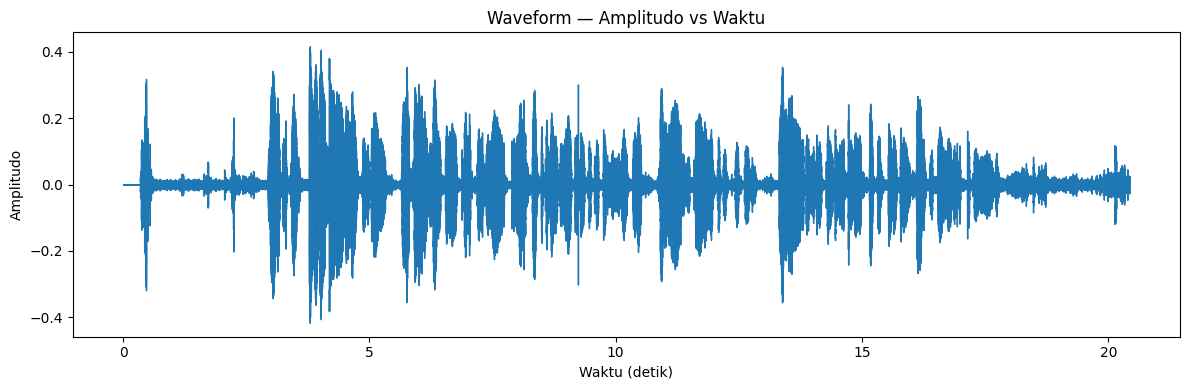

In [72]:
"Bait kode untuk menampilkan grafik waveform dari rekaman audio."

plt.figure() #Untuk membuat figure baru agar tidak menumpuk dengan figure lain
librosa.display.waveshow(y, sr=sr_original) # waveshow butuh sr supaya sumbu-X otomatis dalam satuan detik, bukan indeks sampel mentah
plt.title("Waveform — Amplitudo vs Waktu")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo") 
plt.tight_layout()  # rapikan margin biar label tidak terpotong
plt.show() 

Berdasarkan waveform di atas, dapat di lihat bahwa 
- Pada detik ~0 - 1 detik amplitudo relatif datar & kecil, fase ini merupakan fase ketika saya belum mulai berbicara.
- Pada detik ~ 1 - 3 detik terdapat satu ledakan amplitudo lalu turun lagi. Ledakan amplitudo itu bisa jadi bersumber dari suara ketika saya mungkin tidak sengaja menyentuh perangkat rekam
- Pada detik ~ 3 - 19 detik dapat dilihat pada waveform bahwa amplitudo relatif naik turun atau fluktuasi tinggi dan rapat terus menerus, ini merupakan bagian saya aktif membaca sebuah artikel.
- Pada detik ~ 19 - 20.4 amplitudo kembali turun lagi ke level kecil, ini terjadi karena saya sudah berhenti berbicara, sehingga hanya tersisa noise statis dari kipas.

### 2.2 Spektrum FFT (dBFS Terkalibrasi)

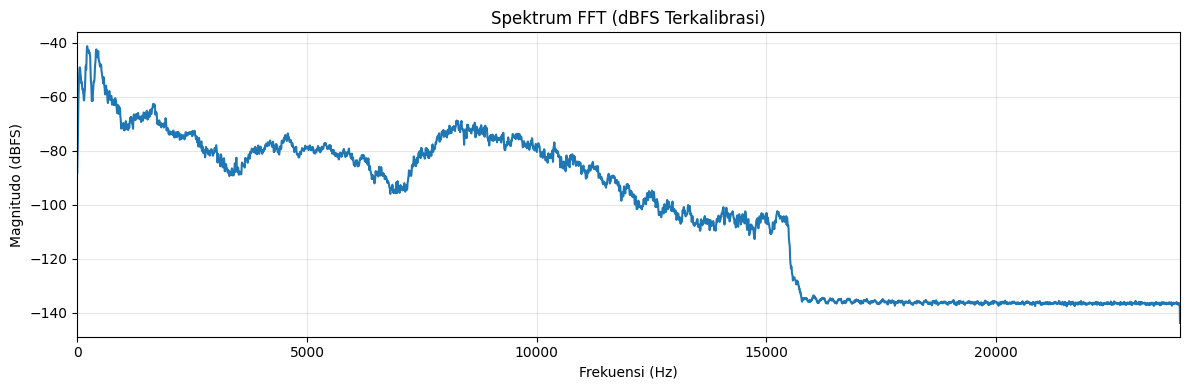

5 frekuensi dengan magnitudo tertinggi (Hz): [216.8 210.9 222.7 416.  240.2]
Magnitudo (dBFS) masing-masing: [-41.3 -41.7 -42.5 -42.5 -42.6]
-143.79193250951556


In [73]:
from scipy.signal import get_window  # window Hann untuk spektrum FFT yang terkalibrasi

def spectrum_dbfs(x, sr, n_fft=8192):
    """Menghitung spektrum satu sisi berskala dBFS yang benar-benar terkalibrasi
    (mengikuti metode yang diajarkan pada Modul 02, bukan sekadar 20*log10(abs(rfft(x)))).
    """
    x = np.asarray(x, dtype=float)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))

    w = get_window('hann', n_fft, fftbins=True)     # window Hann meredam efek potongan tiba-tiba di tepi sinyal
    hop = n_fft // 2                                 # overlap 50% antar jendela
    n_frames = 1 + (len(x) - n_fft) // hop           # jumlah jendela yang muat di seluruh durasi sinyal

    akumulasi = np.zeros(n_fft // 2 + 1)
    for i in range(n_frames):
        seg = x[i * hop: i * hop + n_fft]
        akumulasi += np.abs(np.fft.rfft(seg * w))    # FFT tiap jendela, dijumlahkan (nanti dirata-rata)
    mag = akumulasi / n_frames / np.sum(w)           # normalisasi thd SUM WINDOW (bukan cuma dibagi max!)

    # Koreksi spektrum satu sisi (x2) karena rfft cuma ambil setengah spektrum;
    # dikecualikan pada bin DC (indeks 0) & Nyquist (indeks terakhir) yang tak berpasangan
    mag[1:-1] *= 2.0

    db = 20 * np.log10(np.maximum(mag, 1e-12))       # ubah ke dBFS, dibatasi bawah agar tak -infinity
    freqs = np.fft.rfftfreq(n_fft, 1 / sr)
    return freqs, db

freqs, magnitude_db = spectrum_dbfs(y, sr_original)

plt.figure()
plt.plot(freqs, magnitude_db)
plt.title("Spektrum FFT (dBFS Terkalibrasi)")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitudo (dBFS)")
plt.xlim(0, sr_original / 2)   # batas Nyquist
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5 frekuensi dengan magnitudo tertinggi -> kandidat frekuensi dominan noise/vokal
idx_dominan = np.argsort(magnitude_db)[-5:][::-1]
print("5 frekuensi dengan magnitudo tertinggi (Hz):", np.round(freqs[idx_dominan], 1))
print("Magnitudo (dBFS) masing-masing:", np.round(magnitude_db[idx_dominan], 1))
print(magnitude_db.min())

Berdasarkan spektrum FFT (dBFS) di atas, dapat dilihat bahwa
- Magnitudo tertinggi terkonsentrasi di frekuensi rendah, dengan 5 frekuensi dominan berada di bawah 500 Hz (216.8, 210.9, 222.7, 416, 240.2). Ini konsisten dengan karakteristik dengungan kipas yang menjadi sumber noise statis saya, karena energi kompresor kipas memang umumnya terkonsentrasi di rentang frekuensi rendah tersebut.
- Secara umum, magnitudo menurun secara bertahap (roll-off) seiring naiknya frekuensi dari 0 Hz hingga sekitar 15.500 Hz, menunjukkan kombinasi energi noise dan vokal yang semakin melemah di frekuensi tinggi.
- Terdapat patahan tajam pada frekuensi sekitar 15.500-16.000 Hz, di mana magnitudo langsung turun drastis ke noise floor (-143.791 dBFS) dan tetap flat hingga batas Nyquist. 

### 2.3 Spektrogram STFT

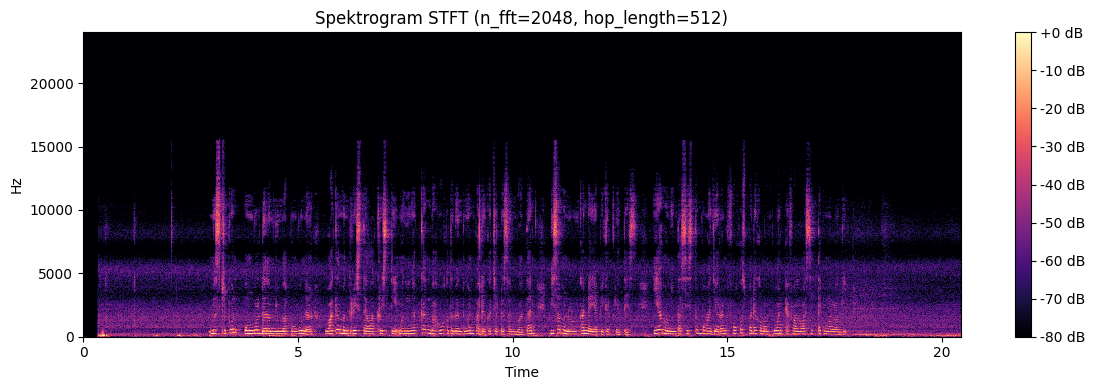

In [74]:
N_FFT = 2048      # ukuran jendela FFT -> resolusi frekuensi Δf = sr/N_FFT (≈23.4 Hz)
HOP = 512         # jarak geser antar jendela -> resolusi waktu = HOP/sr (≈11.6 ms), 75% overlap

D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)         # STFT -> matriks kompleks (waktu x frekuensi)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)    # konversi magnitudo ke skala dB relatif thd puncak

plt.figure()
librosa.display.specshow(S_db, sr=sr_original, hop_length=HOP, n_fft=N_FFT, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spektrogram STFT (n_fft={N_FFT}, hop_length={HOP})")
plt.tight_layout()
plt.show()

Berdasarkan spektrogram STFT di atas, dapat dilihat bahwa
- Terdapat pita horizontal pada rentang frekuensi rendah (~0-5500 Hz) yang muncul konsisten tanpa putus dari awal hingga akhir rekaman, termasuk pada bagian ~19-20.4 detik yang teridentifikasi hening pada analisis waveform sebelumnya. Karena pita ini tetap ada meskipun saya tidak sedang berbicara, ini adalah representasi visual dari noise statis (kipas) yang konsisten dengan definisi noise statis pada soal ("karakteristik statistiknya cenderung konstan").
- Terdapat garis-garis vertikal tipis yang muncul sesaat pada frekuensi hingga 10000-15500 Hz (misalnya di sekitar detik 3, 6-7, 11, 14, dan 17), yang selalu berhimpitan dengan momen saya aktif mengucapkan kata (kemungkinan konsonan/desis tajam seperti "s" atau "t"). Garis ini tidak muncul sama sekali pada bagian hening di akhir rekaman, sehingga dipastikan ini adalah komponen non-statis dari suara saya, bukan noise kipas.
- Terdapat pula "kabut" energi pada rentang 6000-9000 Hz yang hanya muncul berbarengan dengan garis vertikal di atas, dan ikut menghilang pada bagian hening. Pola ini kemungkinan merupakan komponen frikatif (desis) dari artikulasi saya, bukan bagian dari noise statis.
- Pola pita horizontal konstan yang kontras dengan pola vertikal dinamis ini sesuai dengan penjelasan pada soal mengenai perbedaan visual antara noise statis dan harmonik vokal manusia yang naik-turun secara dinamis.

### 2.4 Mel-Spektrogram

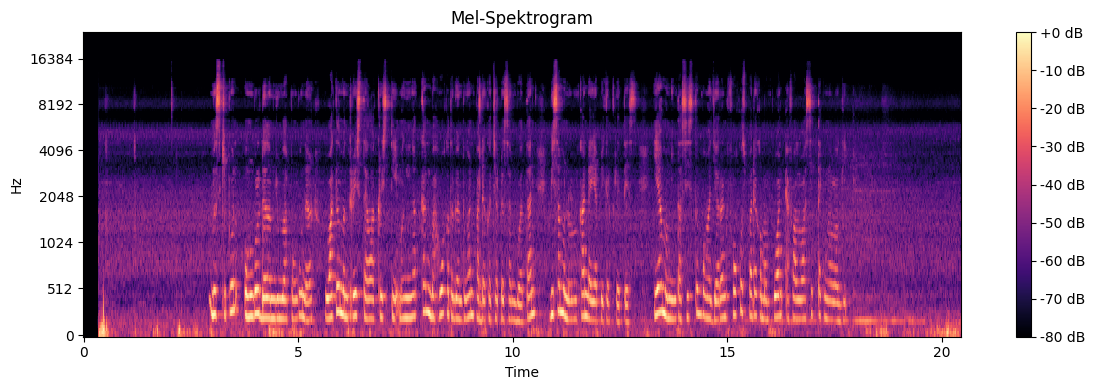

In [75]:
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr_original, n_fft=N_FFT, hop_length=HOP, n_mels=128)
# spektrogram daya dalam skala Mel; n_fft & hop_length disamakan dgn sel STFT agar sumbu waktu konsisten
mel_db = librosa.power_to_db(mel_spec, ref=np.max)   # power_to_db (bukan amplitude_to_db) karena melspectrogram mengembalikan daya (power), bukan magnitudo

plt.figure()
librosa.display.specshow(mel_db, sr=sr_original, hop_length=HOP, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-Spektrogram")
plt.tight_layout()
plt.show()

Berdasarkan Mel-Spektrogram di atas, dapat dilihat bahwa
- Pita energi pada rentang frekuensi rendah (di bawah ~4096 Hz pada skala Mel) tetap konsisten muncul tanpa putus, termasuk pada bagian ~19-20.4 detik yang teridentifikasi hening mengonfirmasi ulang bahwa rentang ini merupakan noise statis (kipas), sejalan dengan temuan pada Spektrum FFT dan Spektrogram STFT sebelumnya.
- Pada rentang di bawah 1024 Hz, khususnya ketika saya sedang aktif berbicara, terlihat garis-garis horizontal yang bertumpuk membentuk pola menyerupai anak tangga. Pola ini merupakan formant (resonansi vokal) dari pita suara saya, dan tampak jauh lebih padat serta jelas dibandingkan pada Spektrogram STFT.
- Kejelasan format ini terjadi karena skala Mel dirancang meniru persepsi pendengaran manusia, yaitu memberi resolusi lebih detail pada frekuensi rendah (tempat formant vokal berada) dan resolusi yang lebih kasar pada frekuensi tinggi, berbeda dengan skala Hz linear pada STFT yang membagi resolusi secara merata di semua frekuensi.
- Garis-garis vertikal yang sebelumnya terlihat tajam hingga 15500 Hz pada STFT (indikasi konsonan/desis) juga tetap tampak pada rentang atas Mel-spektrogram ini, meski resolusinya lebih kasar karena berada di zona frekuensi tinggi skala Mel.

### 3. Eksperimen Resampling & Pembuktian Aliasing

In [76]:
# SKENARIO A — Naive Decimation: ambil tiap sampel ke-M secara langsung TANPA filter LPF anti-aliasing
M = round(sr_original / TARGET_SR_LOW)   # faktor decimation (dibulatkan ke integer terdekat)
y_naive = y[::M]                         # slicing langsung setiap M sampel -> Tidak ada filtering sebelumnya
sr_naive = sr_original / M               # laju sampel efektif setelah decimation

print(f"Faktor decimation (M)       : {M}")
print(f"Laju sampel efektif (naive) : {sr_naive:.1f} Hz")

Faktor decimation (M)       : 6
Laju sampel efektif (naive) : 8000.0 Hz


In [77]:
# SKENARIO B — Resampling Standar: menggunakan filter anti-aliasing (polyphase filtering) bawaan librosa
y_clean = librosa.resample(y, orig_sr=sr_original, target_sr=TARGET_SR_LOW)
sr_clean = TARGET_SR_LOW

print(f"Laju sampel hasil resampling (clean): {sr_clean} Hz")

Laju sampel hasil resampling (clean): 8000 Hz


In [78]:
# Simpan kedua hasil eksperimen sebagai file .wav untuk dilampirkan ke repositori GitHub
sf.write("audio_downsampled_naive.wav", y_naive, int(sr_naive))
sf.write("audio_downsampled_clean.wav", y_clean, sr_clean)
print("Kedua file audio hasil eksperimen sudah disimpan.")

Kedua file audio hasil eksperimen sudah disimpan.


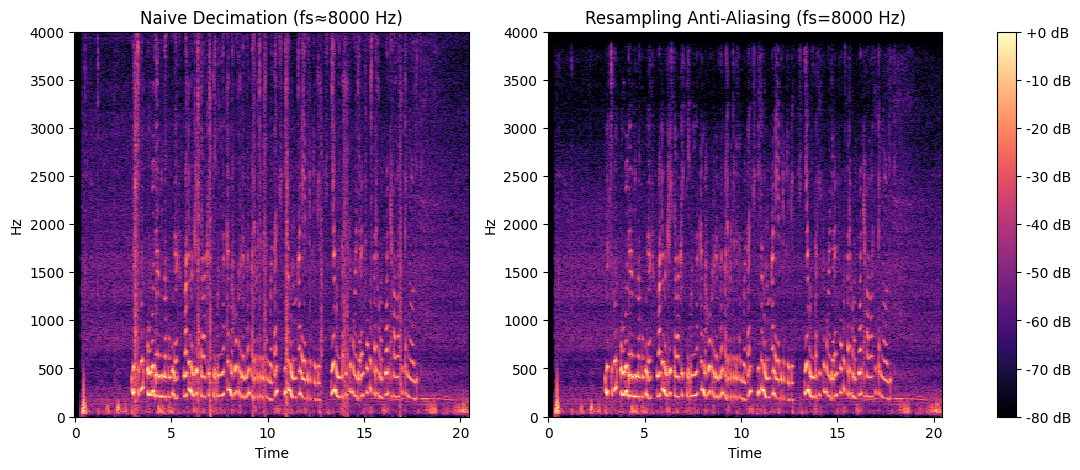

In [79]:
# Bandingkan spektrogram Skenario A vs Skenario B secara berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

D_naive = librosa.stft(y_naive)
S_naive_db = librosa.amplitude_to_db(np.abs(D_naive), ref=np.max)
img1 = librosa.display.specshow(S_naive_db, sr=sr_naive, x_axis='time', y_axis='hz', ax=axes[0])
axes[0].set_title(f"Naive Decimation (fs≈{sr_naive:.0f} Hz)")

D_clean = librosa.stft(y_clean)
S_clean_db = librosa.amplitude_to_db(np.abs(D_clean), ref=np.max)
img2 = librosa.display.specshow(S_clean_db, sr=sr_clean, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title(f"Resampling Anti-Aliasing (fs={sr_clean} Hz)")

fig.colorbar(img2, ax=axes, format='%+2.0f dB')
plt.show()

Berdasarkan perbandingan kedua spektrogram di atas, dapat dilihat bahwa
- Pada Skenario A (Naive Decimation), rentang frekuensi ~2000-4000 Hz (mendekati batas Nyquist baru) menunjukkan tekstur "kabut" tambahan yang cukup padat dan hampir kontinu selama fase bicara aktif (~3-18 detik), berbeda dengan Skenario B (Resampling Anti-Aliasing) yang pada rentang sama tampak lebih bersih/gelap di luar titik ledakan konsonan.
- Pola kabut ini merupakan bukti aliasing: energi konsonan/frikatif yang sebelumnya terdeteksi kuat pada rentang ~5000-9000 Hz (lihat analisis Spektrogram STFT) tidak dibuang saat decimation langsung ke fs=8000 Hz, melainkan "terlipat balik" ke frekuensi rendah (misalnya komponen ~6000 Hz terpantul menjadi ~2000 Hz, mengikuti rumus fs_baru - f_asli). Karena momen munculnya energi tinggi ini bertepatan dengan momen bicara aktif, hasil lipatannya pun muncul pada waktu yang sama, menghasilkan kabut tambahan yang selaras dengan ledakan vokal pada Skenario A.
- Pada Skenario B, filter anti-aliasing membuang komponen frekuensi di atas 4000 Hz (Nyquist baru) sebelum proses downsampling dilakukan, sehingga tidak ada komponen tinggi yang tersisa untuk dilipat balik, dan hasilnya tampak lebih bersih di rentang frekuensi yang sama.
- Perbedaan yang teramati relatif lebih halus dibanding contoh aliasing pada umumnya, kemungkinan karena rekaman sumber sudah mengalami pembatasan bandwidth (~16 kHz) akibat kompresi AAC sebelum proses analisis ini dimulai, sehingga materi frekuensi tinggi yang berpotensi menghasilkan aliasing sudah berkurang sejak awal.

### Kesimpulan

Berdasarkan seluruh analisis pada notebook ini, dapat disimpulkan bahwa:

1. **Karakteristik noise statis**: Sumber noise statis yang saya gunakan adalah kipas angin, dengan karakteristik energi yang terkonsentrasi pada rentang frekuensi rendah (dominan di bawah 500 Hz berdasarkan Spektrum FFT), dan membentuk pita horizontal yang konsisten muncul tanpa putus dari awal hingga akhir rekaman pada rentang ~0-5500 Hz (terverifikasi tetap muncul pada Spektrogram STFT maupun Mel-Spektrogram, termasuk pada bagian hening di akhir rekaman).

2. **Temuan paling menonjol dari keempat visualisasi**: Perbedaan pola antara noise statis (pita horizontal konstan, tidak berubah dari waktu ke waktu) dan suara bicara saya (garis-garis vertikal dinamis yang muncul-hilang mengikuti artikulasi, serta formant yang tampak jauh lebih jelas pada Mel-Spektrogram dibanding STFT biasa karena resolusi Mel yang meniru persepsi pendengaran manusia) — kontras ini membuktikan langsung penjelasan pada soal mengenai perbedaan visual noise statis vs harmonik vokal manusia.

3. **Bukti dan penyebab aliasing**: Pada eksperimen resampling, Skenario A (naive decimation) menunjukkan tekstur "kabut" tambahan pada rentang ~2000-4000 Hz yang muncul bersamaan dengan momen bicara aktif, sebagai akibat dari energi konsonan/frikatif (~5000-9000 Hz) yang terlipat balik (folding) karena tidak difilter sebelum laju sampel diturunkan ke 8000 Hz. Skenario B (resampling dengan filter anti-aliasing) tidak menunjukkan pola ini karena komponen di atas frekuensi Nyquist baru (4000 Hz) telah dibuang terlebih dahulu sebelum downsampling dilakukan.
